# Previsão de Vendas de Motos

### 1. Importação das Bibliotecas

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import os

# Create output directory for figures
os.makedirs('data/processed', exist_ok=True)


### 2. Leitura e Preparação dos Dados

Carregamos os dados do arquivo `vendas_3anos.csv`. É importante converter a coluna de data para o formato datetime e defini-la como o índice do DataFrame, o que é essencial para trabalhar com séries temporais.

In [ ]:
df = pd.read_csv('data/raw/vendas_3anos.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Dados Carregados:")
df.head()

Dados Carregados:


,vendas
date,
2023-03-01,8808
2023-04-01,7142
2023-05-01,7845
2023-06-01,7787
2023-07-01,8939


### 3. Visualização dos Dados Históricos

Plotamos os dados históricos para entender visualmente o comportamento da série, como tendência e sazonalidade.

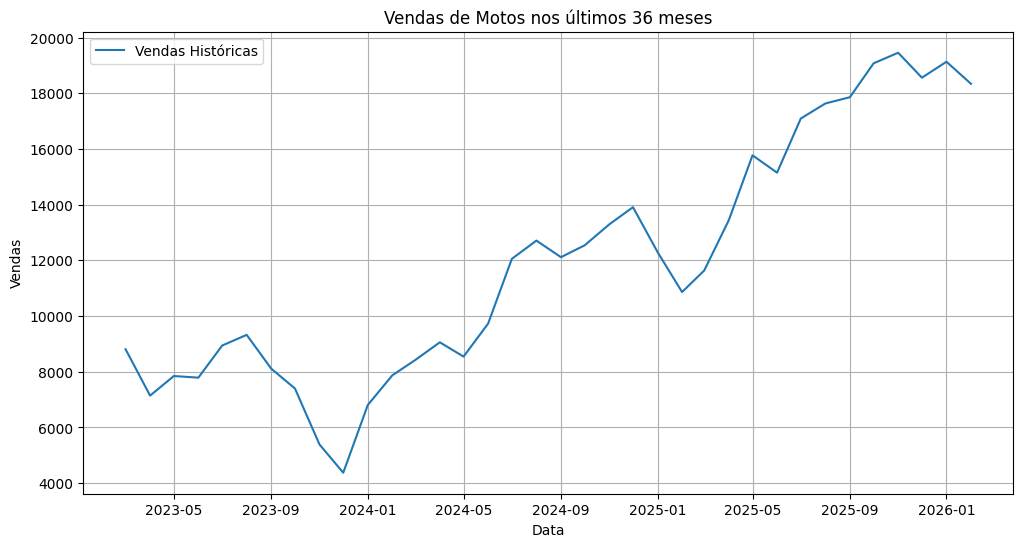

In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['vendas'], label='Vendas Históricas')
plt.title('Vendas de Motos nos últimos 36 meses')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True)
plt.savefig('data/processed/02_historical_sales.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Gráfico de dados históricos salvo em: data/processed/02_historical_sales.png")


### 4. Modelagem e Previsão com Holt-Winters

Utilizamos o modelo `ExponentialSmoothing` (Holt-Winters) para fazer a previsão. Este modelo é bom para séries com tendência e sazonalidade.

- `trend='add'` indica uma tendência aditiva.
- `seasonal='add'` indica uma sazonalidade aditiva.
- `seasonal_periods=12` porque os dados são mensais e esperamos um ciclo anual.

In [ ]:
# Configura e treina o modelo
model = ExponentialSmoothing(df['vendas'], trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()

# Faz a previsão para os próximos 12 meses
forecast = fit.forecast(12)

print("Previsão para os próximos 12 meses:")
print(forecast)

Previsão para os próximos 12 meses:
2026-03-01    19006.246383
2026-04-01    19251.184606
2026-05-01    20093.438273
2026-06-01    20267.702571
2026-07-01    22076.156992
2026-08-01    22604.114404
2026-09-01    22086.496698
2026-10-01    22401.714504
2026-11-01    22121.017003
2026-12-01    21694.185187
2027-01-01    22154.873572
2027-02-01    21764.642741
Freq: MS, dtype: float64


/Users/plucas/Desktop/previsao-de-demanda-aluguel/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### 5. Visualização da Previsão

Finalmente, plotamos os dados históricos junto com a previsão de 12 meses para avaliar o resultado.

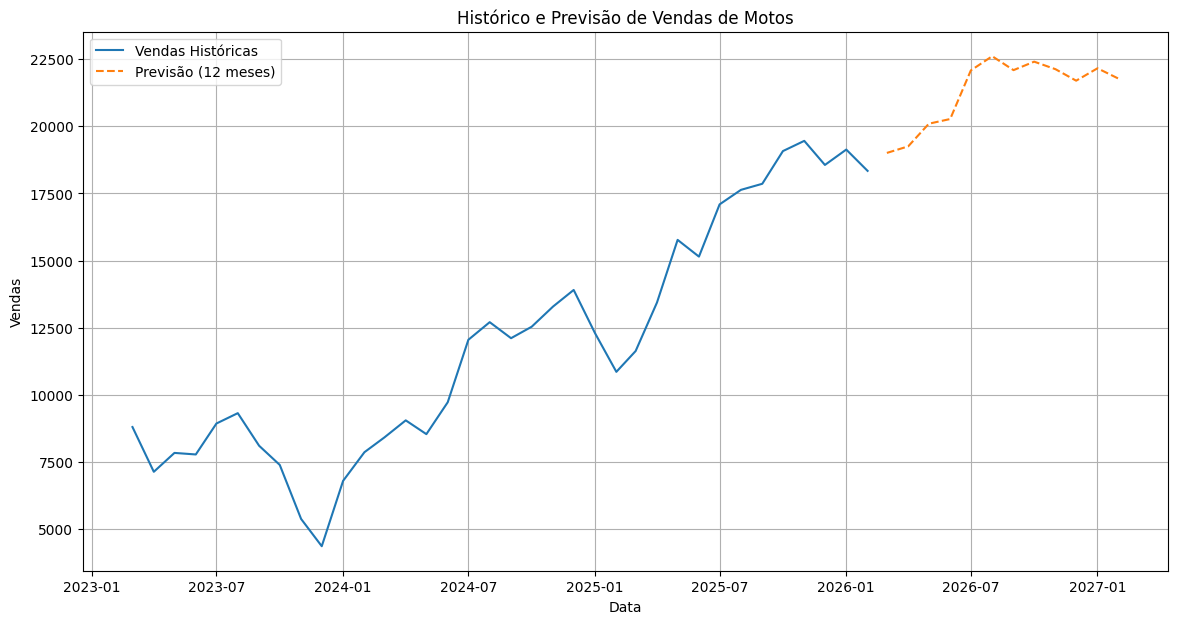

In [ ]:

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['vendas'], label='Vendas Históricas')
plt.plot(forecast.index, forecast, label='Previsão (12 meses)', linestyle='--')
plt.title('Histórico e Previsão de Vendas de Motos')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True)
plt.savefig('data/processed/02_forecast_sales.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Gráfico de previsão salvo em: data/processed/02_forecast_sales.png")
